### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case1_paths, prepare_mouse_fit_data, plot_mouse_growth_fit
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURES_DIR = paths["figures"]
FIGURES_SUPP_DIR = paths["figures_supp"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Load input data
experiment_file = RAW_DIR / "uhn_breast" /  "experiment.csv"
experiment_df = pd.read_csv(experiment_file)

print(f"Loaded experiment data: {experiment_df.shape}")

# Define output file
out_figure_b = FIGURES_DIR / "figure2b_growth_kinetics_breast.png"
out_table_mouse = PROC_DIR / "mouse_doubling_times_breast.csv"
out_table_mouse_qc = PROC_DIR / "mouse_doubling_times_qc_breast.csv"
out_table_model = PROC_DIR / "model_doubling_times_breast.csv"
out_table_model_qc = PROC_DIR / "model_doubling_times_qc_breast.csv"

# Doubling-time estimation parameters
MAX_DAY = 35       # use first 35 days to estimate exponential growth
MIN_POINTS = 3     # minimum number of time points per mouse
MIN_R2 = 0.8       # minimum log-linear fit quality

np.random.seed(101)


Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/procdata
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Loaded experiment data: (32613, 10)


### QC and dataset extraction

In [2]:
# Filter to parental, control-arm, positive-volume measurements
filter_summary = {
    "raw_measurements": len(experiment_df),
}

control_df = experiment_df.copy()

# make "model.type" all to lowercase for filtering
control_df = control_df[~control_df["model.id"].str.contains("RES", case=False, na=False)]
filter_summary["parental_measurements"] = len(control_df)

control_df = control_df[control_df["drug.id"] == "H2O"]
filter_summary["control_arm_measurements"] = len(control_df)

control_df = control_df[control_df["volume"] > 0]
filter_summary["positive_volume_measurements"] = len(control_df)

print(pd.Series(filter_summary))
print(f"Unique control-arm mice: {control_df['model.id'].nunique()}")

df_raw_exp = control_df

raw_measurements                32613
parental_measurements           24300
control_arm_measurements        13427
positive_volume_measurements    13418
dtype: int64
Unique control-arm mice: 1033


### Fit early-phase log-linear growth models for each control-arm mouse

In [3]:
per_mouse = []
mouse_qc = []

for mouse_id, mouse_df in control_df.groupby("model.id"):
    fit_df = (
        mouse_df.loc[mouse_df["time"] <= MAX_DAY, ["time", "volume"]]
        .dropna()
        .sort_values("time")
    )

    # If multiple records exist for the same mouse/day, average volume first.
    fit_df = (
        fit_df.groupby("time", as_index=False)["volume"]
        .mean()
        .sort_values("time")
    )

    qc_record = {
        "mouse_id": mouse_id,
        "modelID_raw": mouse_id.split(".")[0],
        "n_points_early": fit_df.shape[0],
        "max_day_used": fit_df["time"].max() if not fit_df.empty else np.nan,
        "status": "retained",
        "reason_excluded": "keep", # default, will be updated if meet exclude criteria
    }

    if fit_df.shape[0] < MIN_POINTS:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "too_few_points"
        mouse_qc.append(qc_record)
        continue

    slope, intercept, r, p_value, std_err = linregress(
        fit_df["time"],
        np.log(fit_df["volume"])
    )

    r2 = r**2

    if slope <= 0:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "non_positive_slope"
        qc_record["growth_rate_k"] = slope
        qc_record["r2"] = r2
        mouse_qc.append(qc_record)
        continue

    if r2 < MIN_R2:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "low_r2"
        qc_record["growth_rate_k"] = slope
        qc_record["r2"] = r2
        mouse_qc.append(qc_record)
        continue

    doubling_time = np.log(2) / slope

    per_mouse.append({
        "mouse_id": mouse_id,
        "modelID_raw": mouse_id.split(".")[0],
        "growth_rate_k": slope,
        "doubling_time_days": doubling_time,
        "r2": r2,
        "n_points": fit_df.shape[0],
        "max_day_used": fit_df["time"].max(),
        "intercept": intercept,
        "p_value": p_value,
        "std_err": std_err,
    })

    qc_record["growth_rate_k"] = slope
    qc_record["doubling_time_days"] = doubling_time
    qc_record["r2"] = r2
    mouse_qc.append(qc_record)

per_mouse_df = pd.DataFrame(per_mouse)
mouse_qc_df = pd.DataFrame(mouse_qc)

per_mouse_df.to_csv(out_table_mouse, index=False)
print(f"Mouse-level doubling-time table: {per_mouse_df.shape}")
print(f"Saved to: {out_table_mouse}")

mouse_qc_df.to_csv(out_table_mouse_qc, index=False)
print(f"Mouse-level doubling-time qc saved to: {out_table_mouse_qc}")
print(f"Retained mouse-level fits: {per_mouse_df.shape[0]}\n")
print(mouse_qc_df["reason_excluded"].value_counts(dropna=False))
display(per_mouse_df.head())
display(per_mouse_df.describe())

Mouse-level doubling-time table: (632, 10)
Saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/mouse_doubling_times_breast.csv
Mouse-level doubling-time qc saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/mouse_doubling_times_qc_breast.csv
Retained mouse-level fits: 632

reason_excluded
keep                  632
low_r2                340
non_positive_slope     37
too_few_points         24
Name: count, dtype: int64


,mouse_id,modelID_raw,growth_rate_k,doubling_time_days,r2,n_points,max_day_used,intercept,p_value,std_err
0,01-1104.H2O.m1,01-1104,0.079706,8.696311,0.925596,6,20,5.110866,0.002130,0.011299
1,01-1104.H2O.m2,01-1104,0.092724,7.475367,0.996943,4,20,5.700744,0.001530,0.003631
2,01-1104.H2O.m3,01-1104,0.032437,21.369172,0.881759,11,34,5.058966,0.000018,0.003959
3,01-1104.H2O.m4,01-1104,0.053893,12.861472,0.987995,5,28,5.352585,0.000560,0.003430
4,01-1104.H2O.m5,01-1104,0.054762,12.657357,0.865341,4,19,6.493972,0.069763,0.015275


,growth_rate_k,doubling_time_days,r2,n_points,max_day_used,intercept,p_value,std_err
count,632.000000,632.000000,632.000000,632.000000,632.000000,632.000000,6.320000e+02,632.000000
mean,0.059665,15.894984,0.927920,7.311709,29.094937,5.078263,1.039387e-02,0.007074
std,0.038451,9.286464,0.052291,2.667404,6.773948,0.659047,3.225182e-02,0.007076
min,0.009871,2.422609,0.800412,3.000000,6.000000,-1.494996,3.289353e-10,0.000311
25%,0.035265,9.677799,0.887349,5.000000,27.000000,4.751753,1.100180e-05,0.003459
50%,0.050449,13.739552,0.941353,6.000000,32.000000,5.021265,3.167553e-04,0.005171
75%,0.071622,19.655715,0.970998,10.000000,34.000000,5.397167,5.184311e-03,0.008010
max,0.286116,70.222959,0.999995,12.000000,35.000000,7.085034,2.882568e-01,0.076820


### Follow-up duration vs. growth rate (motivates a bounded MAX_DAY)

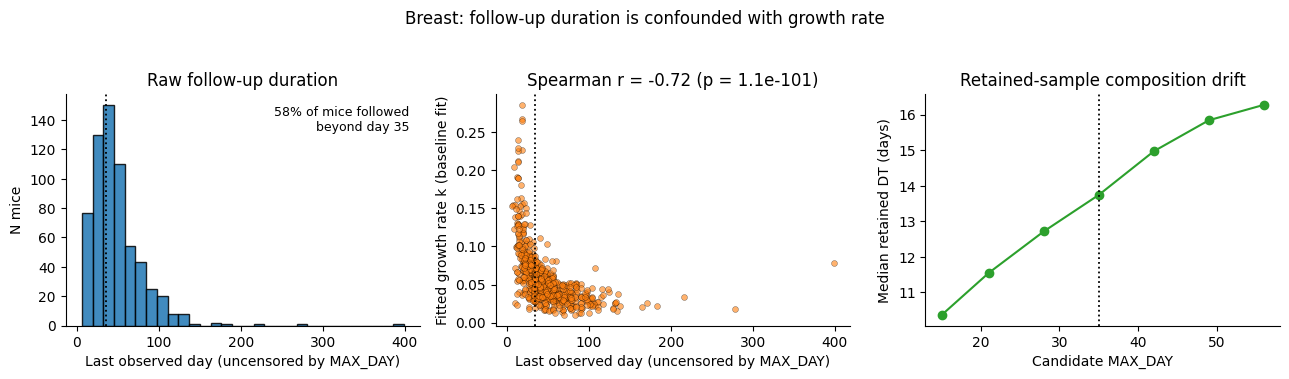

Saved follow-up censoring table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/followup_censoring_breast.csv
Saved MAX_DAY composition-drift table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/maxday_composition_drift_breast.csv
Saved follow-up censoring figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1b_followup_censoring_breast.png


In [4]:
from pipeline_utils import (
    compute_followup_censoring,
    compute_maxday_composition_drift,
    plot_followup_censoring,
)

censoring_df = compute_followup_censoring(control_df, per_mouse_df)
drift_df = compute_maxday_composition_drift(
    control_df,
    max_day_grid=[15, 21, 28, 35, 42, 49, 56],
    min_points=MIN_POINTS,
    min_r2=MIN_R2,
    modelid_split_index=0,
)

out_table_followup_censoring = PROC_DIR / "followup_censoring_breast.csv"
out_table_maxday_drift = PROC_DIR / "maxday_composition_drift_breast.csv"
out_figure_followup_censoring = FIGURES_SUPP_DIR / "supp_figure1b_followup_censoring_breast.png"

censoring_df.to_csv(out_table_followup_censoring, index=False)
drift_df.to_csv(out_table_maxday_drift, index=False)
plot_followup_censoring(
    censoring_df, drift_df, max_day=MAX_DAY, out_path=out_figure_followup_censoring, cohort_label="Breast"
)
plt.show()

print(f"Saved follow-up censoring table to: {out_table_followup_censoring}")
print(f"Saved MAX_DAY composition-drift table to: {out_table_maxday_drift}")
print(f"Saved follow-up censoring figure to: {out_figure_followup_censoring}")

### QC threshold sensitivity (MIN_POINTS, MIN_R2)

One-parameter-at-a-time sweep against the pipeline defaults (`MIN_POINTS=3`, `MIN_R2=0.8`, dotted line in each panel; `MAX_DAY` fixed at 35).

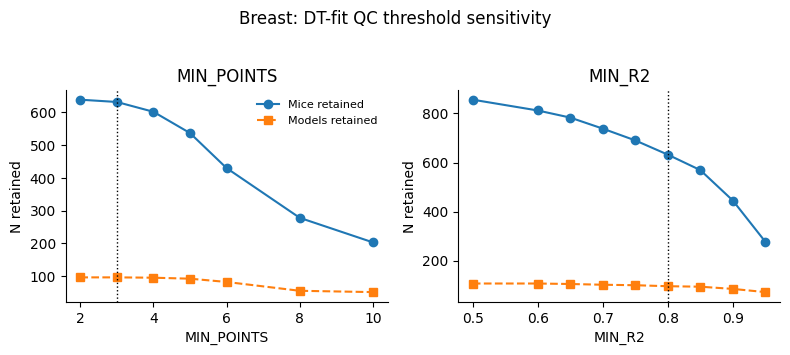

Saved sensitivity table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/qc_threshold_sensitivity_breast.csv
Saved sensitivity figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1a_qc_threshold_sensitivity_breast.png


,parameter,value,is_baseline,n_mice_retained,n_models_retained,median_doubling_time_days,mean_r2
1,MIN_POINTS,3.0,True,632,96,13.739552,0.92792
12,MIN_R2,0.8,True,632,96,13.739552,0.92792


In [5]:
from pipeline_utils import qc_threshold_sensitivity, plot_qc_threshold_sensitivity

min_points_grid = [2, 3, 4, 5, 6, 8, 10]
min_r2_grid = [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

sensitivity_df = qc_threshold_sensitivity(
    control_df,
    baseline_max_day=MAX_DAY,
    baseline_min_points=MIN_POINTS,
    baseline_min_r2=MIN_R2,
    min_points_grid=min_points_grid,
    min_r2_grid=min_r2_grid,
    modelid_split_index=0,
)

out_table_qc_sensitivity = PROC_DIR / "qc_threshold_sensitivity_breast.csv"
out_figure_qc_sensitivity = FIGURES_SUPP_DIR / "supp_figure1a_qc_threshold_sensitivity_breast.png"

sensitivity_df.to_csv(out_table_qc_sensitivity, index=False)
plot_qc_threshold_sensitivity(sensitivity_df, out_figure_qc_sensitivity, cohort_label="Breast")
plt.show()

print(f"Saved sensitivity table to: {out_table_qc_sensitivity}")
print(f"Saved sensitivity figure to: {out_figure_qc_sensitivity}")
display(sensitivity_df.loc[sensitivity_df["is_baseline"]])

### Visualize representative mouse-level growth fits

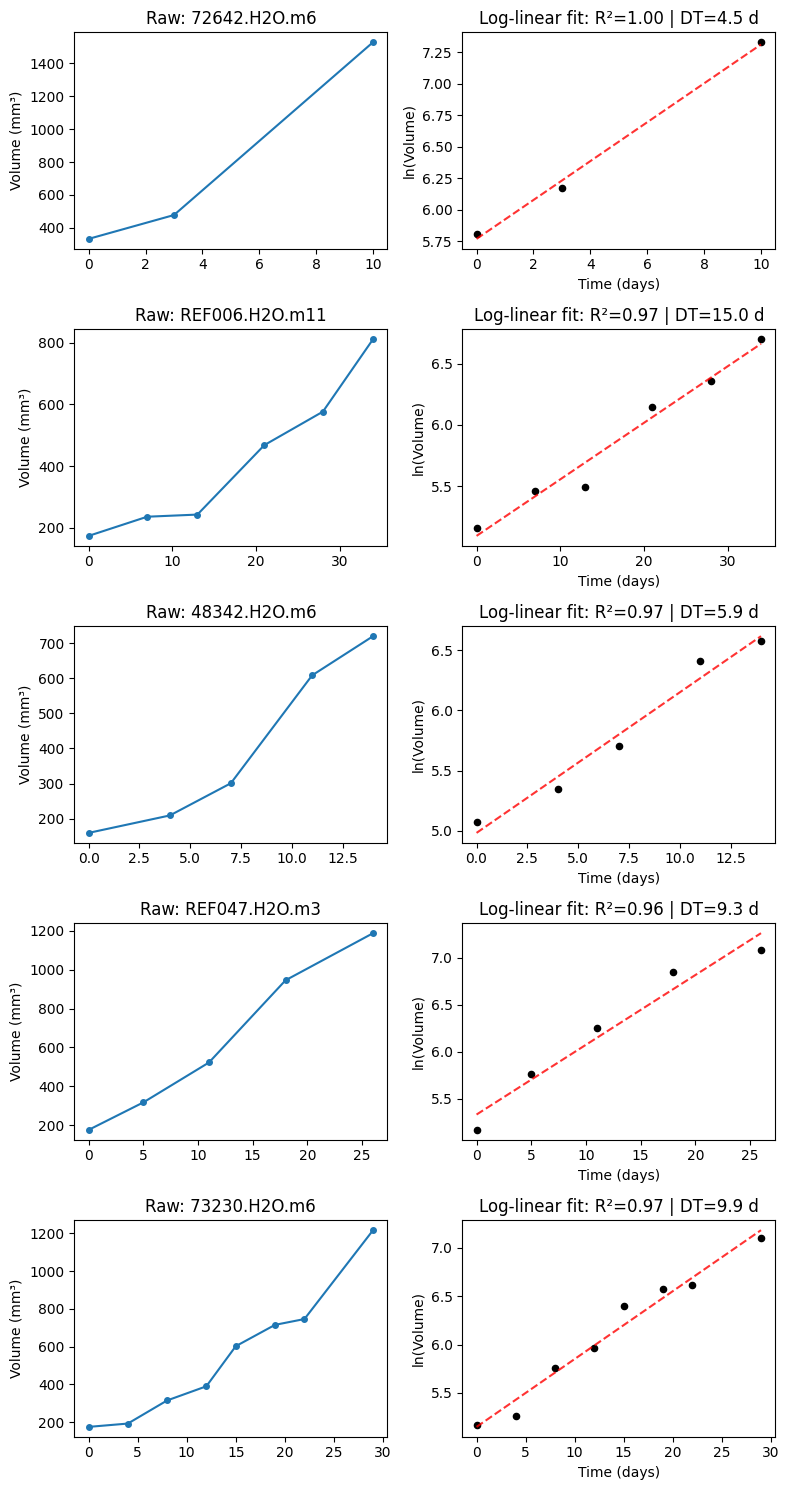

In [6]:
# Pick example mice from retained mouse-level fits
n_examples = 5
RANDOM_STATE = 101
rng = np.random.default_rng(RANDOM_STATE)

example_ids = rng.choice(
    per_mouse_df["mouse_id"],
    size=min(n_examples, per_mouse_df.shape[0]),
    replace=False,
)

fig, axes = plt.subplots(
    nrows=len(example_ids),
    ncols=2,
    figsize=(8, 3 * len(example_ids)),
    sharex=False,
)

if len(example_ids) == 1:
    axes = np.array([axes])

for i, mouse_id in enumerate(example_ids):
    plot_mouse_growth_fit(mouse_id, axes[i, 0], axes[i, 1], control_df)

plt.tight_layout()
plt.show()

### Representative growth-curve fit for Figure 2b

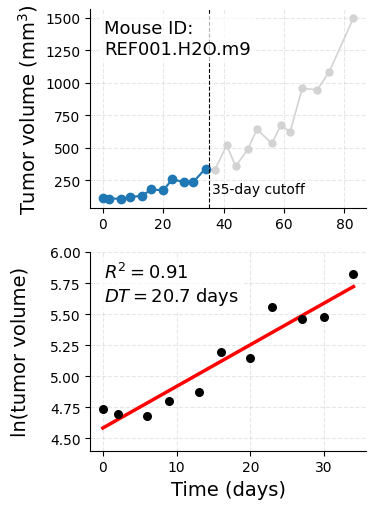

Saved figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_main/figure2b_growth_kinetics_breast.png


In [7]:
target_mouse = "REF001.H2O.m9"

# Load mouse-level control-arm data
mouse_all_df = (
    control_df.loc[control_df["model.id"] == target_mouse, ["time", "volume"]]
    .dropna()
    .sort_values("time")
)

if mouse_all_df.empty:
    raise ValueError(f"No control-arm data found for {target_mouse}")

# Early-phase data used for fitting
mouse_fit_df = (
    mouse_all_df.loc[mouse_all_df["time"] <= MAX_DAY]
    .groupby("time", as_index=False)["volume"]
    .mean()
    .sort_values("time")
)

if mouse_fit_df.shape[0] < MIN_POINTS:
    raise ValueError(
        f"{target_mouse} has only {mouse_fit_df.shape[0]} early-phase points; "
        f"minimum required is {MIN_POINTS}"
    )

# Fit log-linear model on early-phase data only
x = mouse_fit_df["time"]
y = np.log(mouse_fit_df["volume"])

slope, intercept, r_val, p_val, std_err = linregress(x, y)
y_pred = intercept + slope * x

r2 = r_val**2
dt_days = np.log(2) / slope if slope > 0 else np.nan

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.8, 5.2))

# Raw volume trajectory: show all points, highlight early fit window
ax1.plot(
    mouse_all_df["time"],
    mouse_all_df["volume"],
    marker="o",
    color="lightgray",
    markersize=5,
    linewidth=1.2,
    label="All control-arm points",
)

ax1.plot(
    mouse_fit_df["time"],
    mouse_fit_df["volume"],
    marker="o",
    color="tab:blue",
    markersize=6,
    linewidth=1.5,
    label=f"Fitted points (≤{MAX_DAY} days)",
)

ax1.set_ylabel("Tumor volume (mm$^3$)", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.3)

ax1.text(
    0.05,
    0.95,
    f"Mouse ID:\n{target_mouse}",
    transform=ax1.transAxes,
    fontsize=13,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="none"),
)

ax1.axvline(MAX_DAY, color="black", linestyle="--", linewidth=0.8)

ax1.text(
    MAX_DAY + 1,
    ax1.get_ylim()[1] * 0.15,
    f"{MAX_DAY}-day cutoff",
    color="black",
    fontsize=10,
    va="top",
)

# Log-linear fit
ax2.scatter(x, y, color="black", s=30, zorder=3)
ax2.plot(x, y_pred, color="red", lw=2.5, zorder=2)

ax2.set_xlabel("Time (days)", fontsize=14)
ax2.set_ylabel("ln(tumor volume)", fontsize=14, labelpad=15)
ax2.grid(True, linestyle="--", alpha=0.3)

ax2.text(
    0.05,
    0.95,
    f"$R^2 = {r2:.2f}$\n$DT = {dt_days:.1f}$ days",
    transform=ax2.transAxes,
    fontsize=13,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="none"),
)

ax2.set_ylim(4.4,6)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(out_figure_b, dpi=300, bbox_inches="tight")
plt.savefig(out_figure_b.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_figure_b}")

### Fit early-phase log-linear growth models for each control-arm model

In [8]:
per_model_df = (
    per_mouse_df.groupby("modelID_raw")
    .agg(
        mean_growth_rate_k=("growth_rate_k", "mean"),
        sd_mouse_doubling_time=("doubling_time_days", "std"),
        n_mice=("mouse_id", "nunique"),
        mean_r2=("r2", "mean"),
        min_r2=("r2", "min"),
        max_day_used=("max_day_used", "max"),
    )
    .reset_index()
    .rename(columns={"modelID_raw": "modelID"})
)

numeric_model_mask = per_model_df["modelID"].str.match(r"^\d", na=False)
per_model_df.loc[numeric_model_mask, "modelID"] = (
    "S" + per_model_df.loc[numeric_model_mask, "modelID"]
)

per_model_df["doubling_time_days"] = np.log(2) / per_model_df["mean_growth_rate_k"]

per_model_df = per_model_df.sort_values("modelID").reset_index(drop=True)

per_model_df.to_csv(out_table_model, index=False)

print(f"Model-level doubling-time table: {per_model_df.shape}")
print(f"Saved to: {out_table_model}")

display(per_model_df.head())
display(per_model_df.describe())

Model-level doubling-time table: (96, 8)
Saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/model_doubling_times_breast.csv


,modelID,mean_growth_rate_k,sd_mouse_doubling_time,n_mice,mean_r2,min_r2,max_day_used,doubling_time_days
0,BPTO180,0.066136,NaN,1,0.879323,0.879323,28,10.480582
1,BPTO200,0.022835,NaN,1,0.826863,0.826863,29,30.354755
2,BPTO51,0.032081,NaN,1,0.856059,0.856059,33,21.605967
3,BPTO95,0.023529,NaN,1,0.922264,0.922264,35,29.459311
4,BXTO64,0.031233,11.716253,5,0.944414,0.885657,35,22.192914


,mean_growth_rate_k,sd_mouse_doubling_time,n_mice,mean_r2,min_r2,max_day_used,doubling_time_days
count,96.000000,72.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,0.056049,6.574296,6.583333,0.922969,0.870535,32.593750,16.427441
std,0.036947,4.899849,5.583183,0.035016,0.052300,4.754119,8.424656
min,0.016928,0.085138,1.000000,0.815200,0.800412,14.000000,2.538804
25%,0.033904,3.181123,1.750000,0.904840,0.825907,33.750000,10.476106
50%,0.047339,5.381368,5.000000,0.926004,0.859718,35.000000,14.643372
75%,0.066165,8.609088,10.250000,0.944844,0.906936,35.000000,20.444712
max,0.273021,25.498413,24.000000,0.999674,0.999674,35.000000,40.945917


### QC summary

In [9]:
qc_summary = pd.Series({
    "Total evaluable PDX models": len(per_model_df),
    "Models with >=2 mice": (per_model_df["n_mice"] >= 2).sum(),
    "Total retained mouse-level fits": per_model_df["n_mice"].sum(),
    "Median DT (days)": round(per_model_df["doubling_time_days"].median(), 2),
    "Mean DT (days)": round(per_model_df["doubling_time_days"].mean(), 2),
    "Min DT (days)": round(per_model_df["doubling_time_days"].min(), 2),
    "Max DT (days)": round(per_model_df["doubling_time_days"].max(), 2),
    "Fast models (DT < 10 days)": (per_model_df["doubling_time_days"] < 10).sum(),
    "Slow models (DT > 40 days)": (per_model_df["doubling_time_days"] > 40).sum(),
    "Mean mouse-level fit R2": round(per_model_df["mean_r2"].mean(), 3),
})

qc_summary.to_csv(out_table_model_qc)
print(f"Model-level doubling-time qc saved to: {out_table_model_qc}")

print(qc_summary)

Model-level doubling-time qc saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/model_doubling_times_qc_breast.csv
Total evaluable PDX models          96.000
Models with >=2 mice                72.000
Total retained mouse-level fits    632.000
Median DT (days)                    14.640
Mean DT (days)                      16.430
Min DT (days)                        2.540
Max DT (days)                       40.950
Fast models (DT < 10 days)          18.000
Slow models (DT > 40 days)           2.000
Mean mouse-level fit R2              0.923
dtype: float64
